In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("/content/cellula toxic data  (1).csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   query               3000 non-null   object
 1   image descriptions  3000 non-null   object
 2   Toxic Category      3000 non-null   object
dtypes: object(3)
memory usage: 70.4+ KB


In [3]:
data.head(5)

,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


# Preprocessing

In [4]:
query=data[['query','Toxic Category']]
query.columns=['text','Toxic Category']
image = data[['image descriptions', 'Toxic Category']]
image.columns=['text','Toxic Category']

In [5]:
data = pd.concat([query, image])

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   text            6000 non-null   object
 1   Toxic Category  6000 non-null   object
dtypes: object(2)
memory usage: 140.6+ KB


In [7]:
data = data.drop_duplicates()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2036 entries, 0 to 220
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   text            2036 non-null   object
 1   Toxic Category  2036 non-null   object
dtypes: object(2)
memory usage: 47.7+ KB


In [8]:
import re
import spacy

nlp = spacy.load("en_core_web_sm")

In [9]:
def preprocess(text):

    text = str(text).lower()

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    doc = nlp(text)

    tokens = []

    for token in doc:

        if token.is_stop:
            continue

        if token.is_punct:
            continue

        if token.is_space:
            continue

        lemma = token.lemma_.strip()

        if lemma == "":
            continue

        tokens.append(lemma)

    return tokens

In [10]:
data["text"]=data["text"].apply(preprocess)

In [11]:
from collections import Counter

counter = Counter()

for sentence in data["text"]:
    counter.update(sentence)

In [12]:
word_to_idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in counter.items():
    if count >= 2:
        word_to_idx[word] = len(word_to_idx)

print(len(word_to_idx))

1655


In [13]:
idx_to_word = {
    idx: word
    for word, idx in word_to_idx.items()
}

In [14]:
encoded_sentences = []

for sentence in data["text"]:

    encoded_sentence = []

    for word in sentence:

        encoded_sentence.append(
            word_to_idx.get(
                word,
                word_to_idx["<UNK>"]
            )
        )

    encoded_sentences.append(encoded_sentence)

In [15]:
print(data["text"].iloc[0])

print(encoded_sentences[0])

['right', 'way', 'handle', 'severe', 'head', 'injury']
[2, 3, 4, 5, 6, 1]


In [16]:
max_length = 20

In [17]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [18]:
X = pad_sequences(
    encoded_sentences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [19]:
X.shape

(2036, 20)

In [20]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [21]:
encoded_category=encoder.fit_transform(data["Toxic Category"])

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,encoded_category,test_size=0.2,random_state=1,stratify=encoded_category)

In [24]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("Class Weights (for reference):", class_weights_dict)

Class Weights (for reference): {0: np.float64(45.22222222222222), 1: np.float64(45.22222222222222), 2: np.float64(1.0896921017402945), 3: np.float64(0.2565799842395587), 4: np.float64(45.22222222222222), 5: np.float64(36.17777777777778), 6: np.float64(2.5841269841269843), 7: np.float64(0.32592592592592595), 8: np.float64(1.5729468599033816)}


In [25]:
import tensorflow as tf


# LSTM

In [26]:
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D

vocab_size = len(word_to_idx)

num_classes = len(encoder.classes_)

model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        mask_zero=True
    ),


    SpatialDropout1D(0.2),


    Bidirectional(LSTM(64, dropout=0.3)),

    Dense(32, activation="relu"),

    Dropout(0.4),

    Dense(num_classes, activation="softmax")

])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
from tensorflow.keras.optimizers import Adam

model.compile(

    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [29]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=35,
    batch_size=32,
    verbose=1)



Epoch 1/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.4115 - loss: 1.9086 - val_accuracy: 0.4608 - val_loss: 1.5735
Epoch 2/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4257 - loss: 1.5273 - val_accuracy: 0.4730 - val_loss: 1.3926
Epoch 3/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.4988 - loss: 1.3727 - val_accuracy: 0.5392 - val_loss: 1.2857
Epoch 4/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5964 - loss: 1.1907 - val_accuracy: 0.5784 - val_loss: 1.2296
Epoch 5/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6622 - loss: 1.0392 - val_accuracy: 0.5833 - val_loss: 1.2510
Epoch 6/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.6923 - loss: 0.8928 - val_accuracy: 0.5564 - val_loss: 1.3058
Epoch 7/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7402 - loss: 0.7452 - val_accuracy: 0.5735 - val_loss: 1.5310
Epoch 8/35
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7647 - loss: 0.6641 - val_accuracy: 0.5637 - 

In [30]:
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [31]:
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix

In [32]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

f1 = f1_score( y_test , y_pred ,average="weighted")

print("F1 Score :", f1)

Accuracy : 0.5318627450980392
F1 Score : 0.5205250806572143


In [36]:
from sklearn.metrics import classification_report, confusion_matrix

labels_present = sorted(set(y_test) | set(y_pred))
target_names_present = encoder.classes_[labels_present]

report_text = classification_report(
    y_test, y_pred,
    labels=labels_present,
    target_names=target_names_present,
    zero_division=0
)
print(report_text)

                           precision    recall  f1-score   support

Child Sexual Exploitation       0.00      0.00      0.00         1
                Elections       0.00      0.00      0.00         1
       Non-Violent Crimes       0.27      0.29      0.28        42
                     Safe       0.67      0.67      0.67       177
       Sex-Related Crimes       0.00      0.00      0.00         1
      Suicide & Self-Harm       0.00      0.00      0.00         1
           Unknown S-Type       0.07      0.06      0.06        17
           Violent Crimes       0.51      0.59      0.55       139
                   unsafe       0.27      0.10      0.15        29

                 accuracy                           0.53       408
                macro avg       0.20      0.19      0.19       408
             weighted avg       0.52      0.53      0.52       408



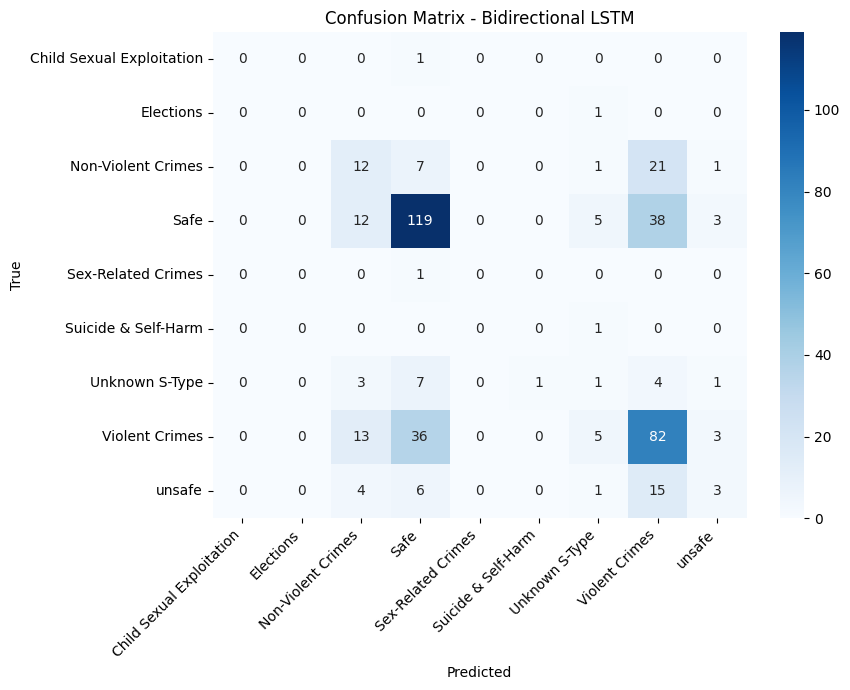

In [37]:
cm = confusion_matrix(y_test, y_pred, labels=labels_present)

plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names_present, yticklabels=target_names_present)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Bidirectional LSTM")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix_lstm.png", dpi=150)
plt.show()

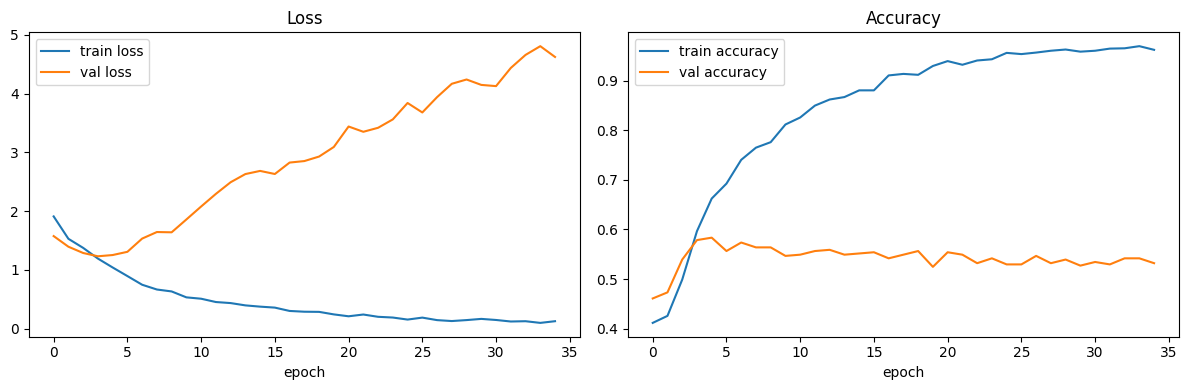

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train accuracy")
axes[1].plot(history.history["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves_lstm.png", dpi=150)
plt.show()